In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

# Load my data

In [3]:
bands = [4, 5, 6, 7]


all_bands    = ["Band 4 nterms2",  "Band 5 robust -1",     "Band 6", "Band 7 nterms2"]
bands_naming = ['Band4_nterms2',   "Band5_robust_minus1",  'Band6',  'Band7_nterms2']
bands_labels = ['Band 4 test',          "Band 5",      'Band 6', 'Band 7']

band_to_index = {band: i for i, band in enumerate(all_bands)}

wavelengths = [lambda_mm[band] for band in bands]
lambda_bands_cm = mm_to_cm(wavelengths)
print(lambda_bands_cm)

colours = [alma_band_colors[band] for band in bands]

[0.21  0.15  0.13  0.087]


In [4]:
f_values = [1, 0.5, 0.3, 0.1]

colours = [alma_band_colors[band] for band in bands]


prefix = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/ZHANG_CODE/MY_npz_files/"

band_prefix = {
    4: 'BAND4/',
    5: 'BAND5/',
    6: 'BAND6/',
    7: 'BAND7/',
}


file_names = {
    '1'   : "dsharp_results_ff_1.00_smoothed_extrapol.npz",
    '0.75': "dsharp_results_ff_0.75_smoothed_extrapol.npz",
    '0.5': "dsharp_results_ff_0.50_smoothed_extrapol.npz",    
    '0.3': "dsharp_results_ff_0.30_smoothed_extrapol.npz",    
    '0.25': "dsharp_results_ff_0.25_smoothed_extrapol.npz",  
    '0.1': "dsharp_results_ff_0.10_smoothed_extrapol.npz"   
}


# Make an array to store the data
data = {}




for band, wav in zip(bands, wavelengths):
    data[wav] = {}

    for f in f_values:
        filename = prefix + band_prefix[band] + file_names[str(f)]
        d = np.load(filename)
        
        data[wav][str(f)] = do_things(d)

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1.2e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 8.5e+02%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1.5e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2.8e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116

In [5]:
df = pd.DataFrame({
    "a_max_micron": data[lambda_mm[4]][str(f)]["a"] * 1e4,
    "P_Band 4": data[lambda_mm[4]][str(f)]["P"],
    "omega_Band 4": data[lambda_mm[4]][str(f)]["omega_eff"],
    "P_times_omega_Band 4": data[lambda_mm[4]][str(f)]["P_omega_eff"],

    "P_Band5": data[lambda_mm[5]][str(f)]["P"],
    "omega_Band5": data[lambda_mm[5]][str(f)]["omega_eff"],
    "P_times_omega_Band5": data[lambda_mm[5]][str(f)]["P_omega_eff"],

    "P_Band6": data[lambda_mm[6]][str(f)]["P"],
    "omega_Band6": data[lambda_mm[6]][str(f)]["omega_eff"],
    "P_times_omega_Band6": data[lambda_mm[6]][str(f)]["P_omega_eff"],

    "P_Band7": data[lambda_mm[7]][str(f)]["P"],
    "omega_Band7": data[lambda_mm[7]][str(f)]["omega_eff"],
    "P_times_omega_Band7": data[lambda_mm[7]][str(f)]["P_omega_eff"],
})

In [6]:
df_POLF = load_POLF(all_bands, print_things = True)

df_POLF

Band = Band 4 nterms2
Band = Band 5 robust -1
Band = Band 6
Band = Band 7 nterms2
 in load_POLF, results = {'Band': ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2'], 'POLF_Gaussian': [1.1646626, 1.3506356000000002, 1.41269695, 0.898293], 'POLF_maxPOLI': [1.561384, 1.5137895000000001, 1.4862873, 1.0841521], 'POLF_err_maxPOLI': [0.040507176933380004, 0.07530999086540001, 0.030210346000000003, 0.014223440147289998], 'POLF_maxStokesI': [1.3677061000000001, 1.4034492, 1.4639224, 1.0421403], 'POLF_err_maxStokesI': [0.03790606194433, 0.07426819624669001, 0.029772913, 0.0141318535827]}


,Band,POLF_Gaussian,POLF_maxPOLI,POLF_err_maxPOLI,POLF_maxStokesI,POLF_err_maxStokesI,POLF_mean
0,Band 4 nterms2,1.164663,1.561384,0.040507,1.367706,0.037906,0.834433
1,Band 5 robust -1,1.350636,1.513790,0.075310,1.403449,0.074268,0.883490
2,Band 6,1.412697,1.486287,0.030210,1.463922,0.029773,0.884578
3,Band 7 nterms2,0.898293,1.084152,0.014223,1.042140,0.014132,0.610588


In [7]:
df_POLF


POLF_type = 'max Stokes I'
plot_sf = 1.5

polf_columns = {
    'gaussian': 'POLF_Gaussian',
    'max Stokes I': 'POLF_maxStokesI',
    'max Stokes I err': 'POLF_err_maxStokesI',
    'POLI': 'POLF_maxPOLI',
    'POLI_err': 'POLF_err_maxPOLI',
    'mean': 'POLF_mean'
}

POLF_obs_all = df_POLF[polf_columns[POLF_type]].values

POLF_obs_for_plot = dict(zip(df_POLF["Band"], df_POLF["POLF_maxStokesI"]))
POLF_err_obs_for_plot = dict(zip(df_POLF["Band"], df_POLF["POLF_err_maxStokesI"]))

In [8]:
# def scale_factor_plot_for_writeup(bands,                  # These are the bands we are looking at
#                                         bands_labels, 
#                                         bands_included_in_fit, # These are the values that were fit
#                                         f_values,            # These are the porosity values we are testing
#                                         a_max_dist_micron_by_f,
#                                         P_times_omega_by_f,
#                                         sf_by_f,             # This is the values the data is being scaled by 
#                                         best_idx_by_f, 
#                                         best_a_max_by_f,     # These are the best a_max values for each f
#                                         POLF_markers,        # These are the values for each band we are plotting the marker
#                                         chi_sq_by_f, 
#                                         ymin = -0.1, 
#                                         ymax = 2, 
#                                         xmin = 30, xmax = 1e3 + 20, 
#                                         custom_lw = None,
#                                         custom_text_x = None,
#                                         chi_sq_precision = 2,
#                                         fig_x = 30, fig_y = 8,
#                                         f_fs = 45, 
#                                         f_x = 0.05, f_y = 0.86,
#                                         spine_width = 1,
#                                         included_lw = 5,
#                                         marker_border = False,
#                                         BandLegend_bbox_to_anchor=(0.45, 0.85),
#                                         BandLegend_handletextpad=0.5,
#                                         BandLegend_handlelength=1,
#                                         BandLegend_labelspacing=0.6,
#                                         plot_markers = True,
#                                         plot_band_legend = True,
#                                         bands_lw = 5, 
#                                         num_fs = 35,
#                                         xy_axis_fs = 40,
#                                         stats_fs = 35,
#                                         legend_marker_size = 20,
#                                         band_legend_fs = 32.5,
#                                         marker_size = 600,
#                                         plot_sf = False,
#                                         plot_chi_sq = False):
    
    
#     # Set the colors and marker size for each band 
#     band_colors = []
#     ms = []

#     for b in bands:
#         if b == "Band 5 robust -1":
#             band_colors.append(alma_band_colors["Band 5"])
#             ms.append(constants.alma_band_ms["Band 5"])
#         else:
#             band_colors.append(alma_band_colors[b])
#             ms.append(constants.alma_band_ms[b])
    
    
    
#     # Make the figure
#     # Later I will make this so you can customize how many figures you need
#     fig, ax = plt.subplots(1, 4, figsize=(fig_x, fig_y))
    
    
    
    
#     # Loop over the f values you want to plot
#     for i, f in enumerate(f_values): 
        
#         for spine in ax[i].spines.values():
#             spine.set_linewidth(spine_width)
        
       

#         if i == 0:
#             ax[i].set_ylabel('P $\omega$', fontsize = xy_axis_fs)
#         else:
#             ax[i].set_yticklabels([])
#             ax[i].set_ylabel('')
#             ax[i].tick_params(left=False)

#         # Make the x-axis log scale 
#         ax[i].set_xscale("log")
#         ax[i].set_xlim(xmin, xmax)


            
#         fig.supxlabel('Maximum grain size [$\mu$m]', fontsize = xy_axis_fs)
#         ax[i].set_title(f'$f$ = {f:.2f}', fontsize=45)

            
    
#         # Set ticks
#         ax[i].minorticks_on()
#         ax[i].tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4, width=spine_width)
#         ax[i].tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4, width=spine_width)
        
        
#         # Control the font size of the numbers on the axes
#         # ---------------------------------------------------------------------------------------
            
#         ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize = num_fs, width=spine_width)
#         ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize = num_fs, width=spine_width)
#         # ---------------------------------------------------------------------------------------
        
        
#         # ---------------------------------------------------------------------------------------
#         # ---------------------------------------------------------------------------------------


           

            
        
# #         if for_poster == True:
# #             ax[i].text(x_pos, 0.15,  f'$\chi^2$ = {chi_sq:.{chi_sq_precision}f}', transform=ax[i].transAxes, fontsize = 30)
#         # ---------------------------------------------------------------------------------------

#         ax[i].set_ylim(ymin, ymax)
#         # ------------------------------------------
        
        
#         marker_handles = []
#         # plot each band for this f
#         for j, b in enumerate(bands):

#             idx = bands.index(b)


# #             print(rf'At band {b}, the POLF_obs value is: {POLF_obs[f][idx]}')
# #             print(' ')

#             fc = band_colors[j]

#             if marker_border:
#                 ec = 'black'
#                 marker_lw = 1.5
#             else:
#                 ec = band_colors[j]
#                 marker_lw = 0
#             #ec = band_colors[j]
# #             marker_lw = 0 

# #             if for_poster and b == "Band 5 robust -1":
# #                 fc = alma_band_colors["Band 5"]
# #                 ec = alma_band_colors["Band 5"]

#             if b == "Band 5" and not for_poster:
#                 fc = 'none'
#                 marker_lw = 5

#             # Plot the POLF markers
#             plot_marker = True

#             if b == "Band 5":
#                 plot_marker = False

#             if plot_markers:
#                 ax[i].scatter(
#                     best_a_max_by_f[f],
#                     POLF_markers[b],
#                     marker=ms[j], 
#                     s=marker_size,
#                     facecolors=fc,
#                     edgecolors=ec,
#                     linewidths=marker_lw,
#                     zorder = 5
#                 )
#         # ---------------------------------------------------------------------


#             marker_handles.append(
#             Line2D([0], [0],
#                    marker=ms[j],
#                    color='none',
#                    markerfacecolor=fc,
#                    markeredgecolor=ec,
#                    markeredgewidth=marker_lw,
#                    markersize=15,
#                    linestyle='None'))

#        # if b not in ["Band 5 robust -1", "Band 5 robust -2"]:
#             ax[i].plot(a_max_dist_micron_by_f[f],
#                            P_times_omega_by_f[f][:, idx] * sf_by_f[f],
#                            color=band_colors[j],
#                            label=b,
#                            lw=bands_lw,
#                            ls='-' if b in bands_included_in_fit else '--',
#                            zorder = 1)
        
                
#         x_pos = 0.05 
        
#         if custom_text_x is not None:
#             x_pos = x_pos + custom_text_x[i]
        
#         if plot_chi_sq:
#             ax[i].text(x_pos, 0.8,  f'$\chi^2$ = {chi_sq_by_f[f]:.{chi_sq_precision}f}', transform=ax[i].transAxes, fontsize = stats_fs)

#         if plot_sf:
#             ax[i].text(x_pos, 0.7, f'sf = {sf_by_f[f]:.2f}', transform=ax[i].transAxes, fontsize = stats_fs)


#         # Add the a_max to the text
#         ax[i].text(x_pos, 0.9, rf'$a_{{\mathrm{{max}}}}$ = {best_a_max_by_f[f]:.0f} $\mu$m', 
#                    transform=ax[i].transAxes, 
#                    fontsize = stats_fs)
        
        
        
#     #plt.tight_layout()
    
#     plt.subplots_adjust(
#         left=0.05,
#         right=0.98,
#         bottom=0.15,
#         top=0.95,
#         wspace=0.02
#     )
    
    
#     # Add coloured text for each Band in the far right plot
#     # ----------------------------------------------------
#     # ----------------------------------------------------
#     #start = start # This is the starting vertical position
#     c = 0
#     marker_legend_handles = []
    
#     # Choose legend entries
#     legend_bands = ["Band 4", "Band 5 robust -1", "Band 6", "Band 7"]

#     for b_label in legend_bands:

#         if b_label == "Band 5 robust -1":
#             label = "Band 5"
#             color = alma_band_colors["Band 5"]
#             marker = constants.alma_band_ms["Band 5"]
#         else:
#             label = b_label
#             color = alma_band_colors[b_label]
#             marker = constants.alma_band_ms[b_label]


#         handle = Line2D(
#             [0], [0],
#             marker=marker,
#             color='none',
#             markerfacecolor=color,
#             markeredgecolor=color,
#             markersize=legend_marker_size,
#             linestyle='None',
#             label=label
#         )

#         marker_legend_handles.append(handle)
        
        
        
#     legend_elements = [
#         Line2D([0], [0], color='black', linestyle='-', lw = 5, label='Included'),
#         Line2D([0], [0], color='black', linestyle='--', lw = 5, label='Excluded')
#     ]
#     # ----------------------------------------------------
#     # ----------------------------------------------------
#     #if plot_markers: 
#     if plot_band_legend:
#         legend = ax[3].legend(
#                 handles=marker_legend_handles,
#                 fontsize= band_legend_fs,
#                 frameon=False,
#                 loc='upper right',
#                 bbox_to_anchor=BandLegend_bbox_to_anchor,
#                 handletextpad=BandLegend_handletextpad, # Cotrols distance between marker and text 
#                 handlelength=BandLegend_handlelength, # Cotrols distance between marker and text 
#                 labelspacing=BandLegend_labelspacing # Controls vertical gap between the markers
#             )

#         legend_colors = [
#             alma_band_colors["Band 4"],
#             alma_band_colors["Band 5"],
#             alma_band_colors["Band 6"],
#             alma_band_colors["Band 7"]
#         ]

#         for text, color in zip(legend.get_texts(), legend_colors):
#             text.set_color(color)
# #     # ----------------------------------------------------
# #     # ----------------------------------------------------



# # 

#     return fig, ax
# # -----------------------------------------------------------------------------------
# # -----------------------------------------------------------------------------------

In [9]:
lambda_mm

{1: 7.0,
 3: 3.1,
 4: 2.1,
 42: 2.1,
 'Band 4': 2.1,
 'Band 4 nterms2': 2.1,
 'Band 4 nterms2 robust -1': 2.1,
 'Band 4 nterms2 smooth': 2.1,
 'Band 4 nterms2 smooth B6': 2.1,
 'Band 4 nterms2 smooth B6 B7': 2.1,
 5: 1.5,
 50: 1.5,
 52: 1.5,
 'Band 5': 1.5,
 'Band 5 robust -2': 1.5,
 'Band 5 robust -1': 1.5,
 51: 1.7,
 6: 1.3,
 'Band 6': 1.3,
 'Band 6 smooth': 1.3,
 'Band 6 smooth B7': 1.3,
 7: 0.87,
 72: 0.87,
 'Band 7': 0.87,
 'Band 7 nterms2': 0.87,
 'Band 7 nterms2 smooth': 0.87,
 'Band 7 nterms2 smooth B6': 0.87,
 10: 0.34}

## All bands

In [10]:
bands_fit = ["Band 4 nterms2",  "Band 5 robust -1", "Band 6", "Band 7 nterms2"]

fit_indices_all = [band_to_index[b] for b in bands_fit]


a_max_dist_micron_all, P_times_omega_all, a_max_best_all, POLF_obs_all, best_sf_all, best_idx_all, chi_sq_all = find_sf_v5(
    all_bands,
    bands_naming,
    bands_fit,
    data,
    f_values,
    wavelengths,
    df_POLF,
    POLF_type,
    print_results=True
)


The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
fit_indicies: [0, 1, 2, 3]
fit_indicies: [0, 1, 2, 3]
fit_indicies: [0, 1, 2, 3]
fit_indicies: [0, 1, 2, 3]
Best idx: {1: 1365, 0.5: 1441, 0.3: 1471, 0.1: 1514}
Best a_max: {1: 161.6781583796315, 0.5: 243.9504024388366, 0.3: 286.9599902180372, 0.1: 362.1593843013101}
Best SF: {1: 2.241094536721723, 0.5: 2.1332612428430147, 0.3: 2.2604336801363862, 0.1: 2.9517593098475468}
Best chi^2: {1: 28.651785810656282, 0.5: 1.3120834648746578, 0.3: 2.6437056149158225, 0.1: 6.125398290653272}


In [11]:
bands_labels

['Band 4 test', 'Band 5', 'Band 6', 'Band 7']

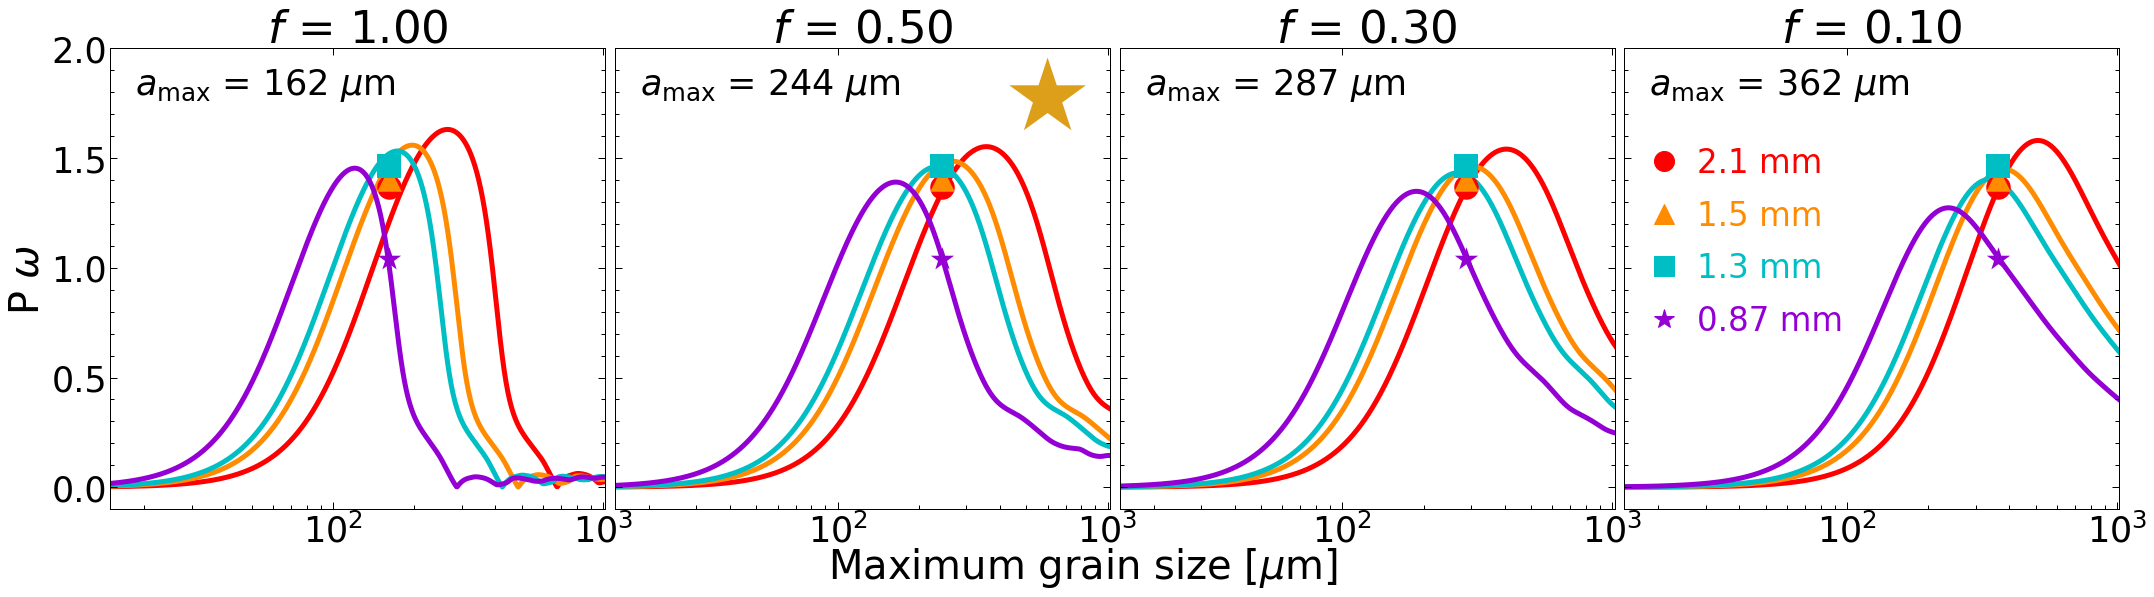

In [12]:
fig, ax = scale_factor_plot_for_writeup(all_bands, 
                                        bands_labels, 
                                        bands_fit, 
                                        f_values,                               
                                        a_max_dist_micron_all, 
                                        P_times_omega_all,
                                        best_sf_all, 
                                        best_idx_all, 
                                        a_max_best_all, 
                                        POLF_obs_for_plot,
                                        chi_sq_all,
                                        plot_sf = False,
                                        plot_chi_sq = False, 
#                                         plot_sf = True,
#                                         plot_chi_sq = True, 
                                        )



ax[1].text(
    0.85, 0.88,
    r'$\star$',
    transform=ax[1].transAxes,
    fontsize=200,
    color= '#dd9e1aff',
    ha='center',
    va='center'
)



# Plot lines so I can see if its correct 
plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_AllBands_ZhangMethod.pdf", 
            dpi=300, 
            bbox_inches='tight')

In [13]:
# raise SystemExit("Stop here")

## No 5

In [14]:
bands_wo5 = ["Band 4 nterms2",  "Band 6", "Band 7 nterms2"]
fit_indices_wo5 = [band_to_index[b] for b in bands_wo5]

a_max_dist_micron_wo5, P_times_omega_wo5, a_max_best_wo5, POLF_obs_wo5, best_sf_wo5, best_idx_wo5, chi_sq_wo5 = find_sf_v5(
    all_bands,
    bands_naming,
    bands_wo5,
    data,
    f_values,
    wavelengths,
    df_POLF,
    POLF_type
)

The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 6', 'Band 7 nterms2']
fit_indicies: [0, 2, 3]
fit_indicies: [0, 2, 3]
fit_indicies: [0, 2, 3]
fit_indicies: [0, 2, 3]


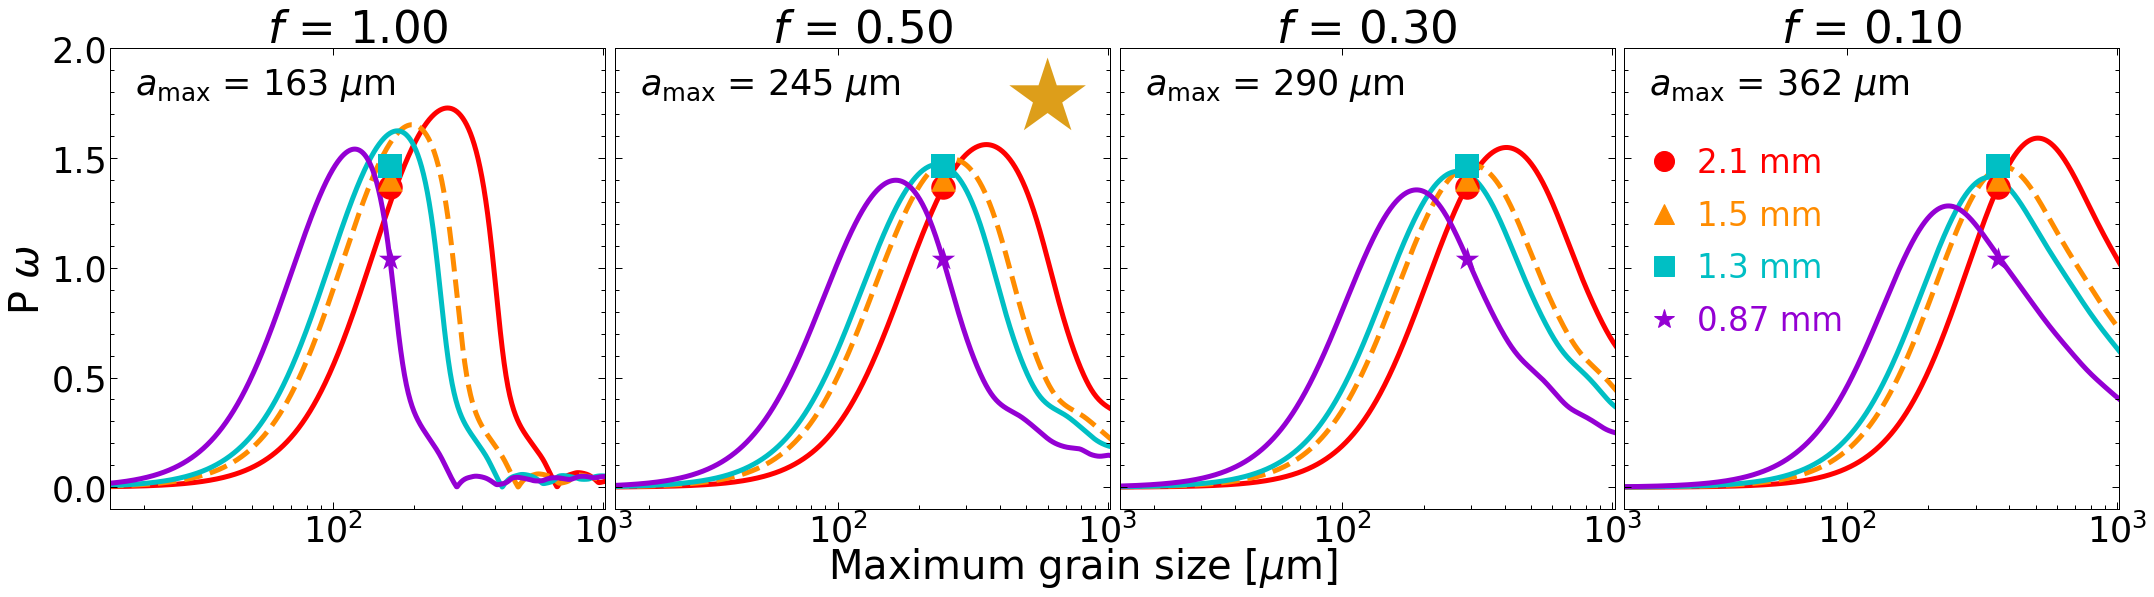

In [15]:
fig, ax = scale_factor_plot_for_writeup(all_bands, 
                                        bands_labels, 
                                        bands_wo5, 
                                        f_values,                               
                                        a_max_dist_micron_wo5, 
                                        P_times_omega_wo5,
                                        best_sf_wo5, 
                                        best_idx_wo5, 
                                        a_max_best_wo5, 
                                        POLF_obs_for_plot,
                                        chi_sq_wo5,
                                        plot_sf = False,
                                        plot_chi_sq = False, 
#                                         plot_sf = True,
#                                         plot_chi_sq = True, 
                                        )
    
    

ax[1].text(
    0.85, 0.88,
    r'$\star$',
    transform=ax[1].transAxes,
    fontsize=200,
    color= '#dd9e1aff',
    ha='center',
    va='center'
)


# Also want to plot Band 5 data 
plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_Without5_ZhangMethod.pdf", 
            dpi=300, 
            bbox_inches='tight')

## No 6

In [16]:
bands_wo6 = ["Band 4 nterms2", "Band 5 robust -1",  "Band 7 nterms2"]
fit_indices_wo6 = [band_to_index[b] for b in bands_wo6]


a_max_dist_micron_wo6, P_times_omega_wo6, a_max_best_wo6, POLF_obs_wo6, best_sf_wo6, best_idx_wo6, chi_sq_wo6 = find_sf_v5(
    all_bands,
    bands_naming,
    bands_wo6,
    data,
    f_values,
    wavelengths,
    df_POLF,
    POLF_type
)


The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 7 nterms2']
fit_indicies: [0, 1, 3]
fit_indicies: [0, 1, 3]
fit_indicies: [0, 1, 3]
fit_indicies: [0, 1, 3]


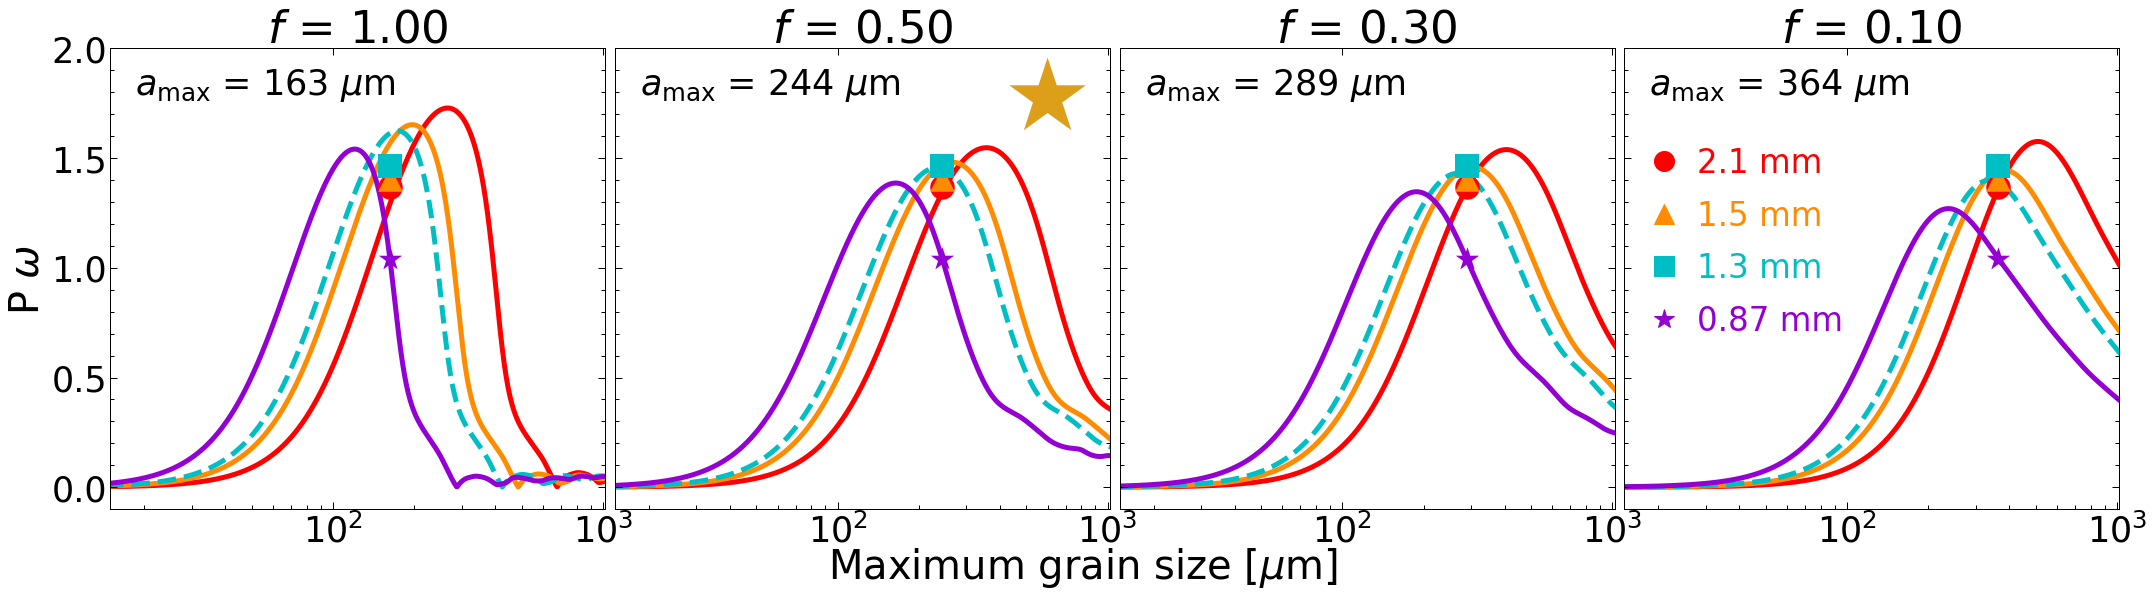

In [17]:
fig, ax = scale_factor_plot_for_writeup(all_bands, 
                                        bands_labels, 
                                        bands_wo6, 
                                        f_values,                               
                                        a_max_dist_micron_wo6, 
                                        P_times_omega_wo6,
                                        best_sf_wo6, 
                                        best_idx_wo6, 
                                        a_max_best_wo6, 
                                        POLF_obs_for_plot,
                                        chi_sq_wo6,
                                        plot_sf = False,
                                        plot_chi_sq = False, 
#                                         plot_sf = True,
#                                         plot_chi_sq = True, 
                                        )


ax[1].text(
    0.85, 0.88,
    r'$\star$',
    transform=ax[1].transAxes,
    fontsize=200,
    color= '#dd9e1aff',
    ha='center',
    va='center'
)


# Also want to plot Band 6 data 
plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_Without6_ZhangMethod.pdf", 
            dpi=300, 
            bbox_inches='tight')

## Just 4, 7

In [18]:
bands_just_47 = ["Band 4 nterms2",   "Band 7 nterms2"]
fit_indices_just_47 = [band_to_index[b] for b in bands_just_47]


a_max_dist_micron_just_47, P_times_omega_just_47, a_max_best_just_47, POLF_obs_just_47, best_sf_just_47, best_idx_just_47, chi_sq_just_47 = find_sf_v5(
    all_bands,
    bands_naming,
    bands_just_47,
    data,
    f_values,
    wavelengths,
    df_POLF,
    POLF_type,
    choose_trouble_index = True,
    trouble = True,
    trouble_f = [0.5], 
    trouble_index = 2, 
)

The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 7 nterms2']
fit_indicies: [0, 3]
fit_indicies: [0, 3]
trouble f = [0.5]
The best a_max is: 2771.711527855742
At this value, the best sf is : 23.628984441513175
 
The second best a_max is: 2712.3478570388324
At this value, the best sf is : 23.560709008623256
 
The third best a_max is: 245.27438713911343
At this value, the best sf is : 2.1521028324353004
 
The fourth best a_max is: 246.60555746183223
At this value, the best sf is : 2.1578162070444584
 
 
fit_indicies: [0, 3]
fit_indicies: [0, 3]


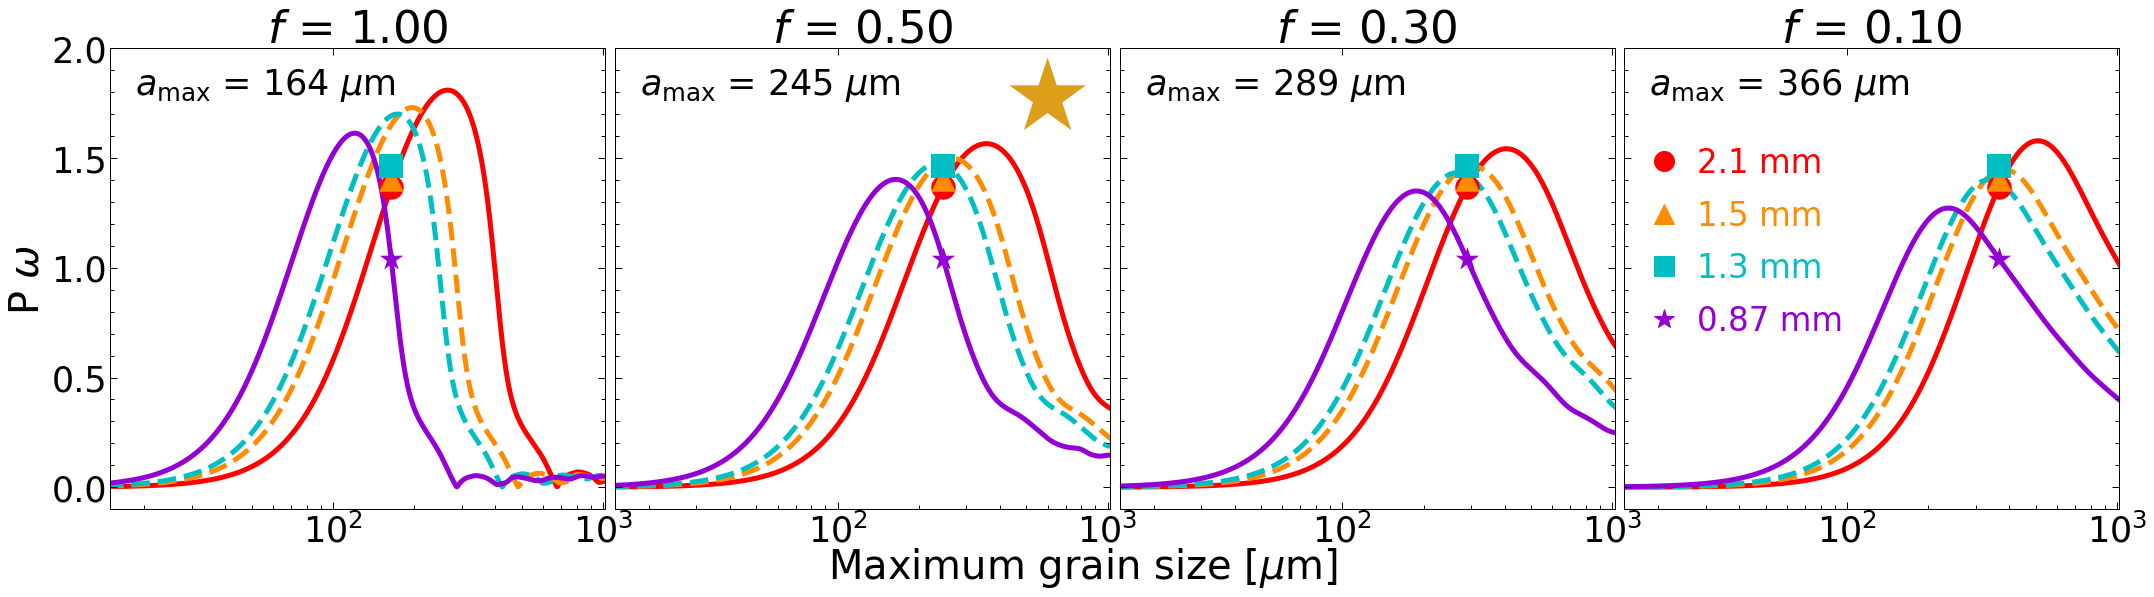

In [19]:
fig, ax = scale_factor_plot_for_writeup(all_bands, 
                                        bands_labels, 
                                        bands_just_47, 
                                        f_values,                               
                                        a_max_dist_micron_just_47, 
                                        P_times_omega_just_47,
                                        best_sf_just_47, 
                                        best_idx_just_47, 
                                        a_max_best_just_47, 
                                        POLF_obs_for_plot,
                                        chi_sq_just_47,
                                        plot_sf = False,
                                        plot_chi_sq = False, 
#                                         plot_sf = True,
#                                         plot_chi_sq = True, 
                                        )

ax[1].text(
    0.85, 0.88,
    r'$\star$',
    transform=ax[1].transAxes,
    fontsize=200,
    color= '#dd9e1aff',
    ha='center',
    va='center'
)


plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_Just47_ZhangMethod.pdf", 
            dpi=300, 
            bbox_inches='tight')